## ALS Recommendation System for Student Projects (Implicit Feedback)

This notebook implements an Alternating Least Squares (ALS) recommendation system for student projects using the **implicit library** specifically designed for **implicit feedback** (interactions).

## Setup
- **Items**: Project titles in Russian from data.xlsx
- **Interactions**: User ratings from artificial_profiles_scores.pkl (converted to implicit)
- **Library**: implicit - designed for implicit feedback

In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import implicit
import warnings

warnings.filterwarnings("ignore")

## Load Data

In [2]:
df = pd.read_excel("data_clean.xlsx", header=0)
df = df.fillna("")
df.drop_duplicates(inplace=True)
print(f"Total projects: {len(df)}")

Total projects: 1187


In [3]:
df.head()

,title_rus,title_eng,annotation,description
0,Исследование приоритетов и механизмов реализац...,Study of Priorities and Mechanisms for Impleme...,Работа международных фондов (доноров) должна п...,"Согласно определению международных фондов, про..."
1,Антрополе - научно-популярный видео-подкаст о ...,Anthropole is a Popular Science Video Podcast ...,"\tАнтрополе - научно-популярный проект, в рамк...","Социальное знание близко и интересно обществу,..."
2,"Разработка, создание и ведение сайта, посвящен...","Design, Development and Implementation of a We...",Художественное образование и творчество художн...,Тема обучения арабских художников в художестве...
3,Перевод с английского языка коллективной моног...,Translation from English of the collective mon...,"Коллективная монография, авторы которой являют...","Коллективная монография, авторы которой являют..."
4,Сеть военно-политических союзов в Евразии: баз...,Network of Military in Eurasia: a Database,Проект посвящен изучению сети военно-политичес...,Проект посвящен анализу истории существования ...


In [4]:
with open("artificial_profiles_scores.pkl", "rb") as f:
    interactions = pickle.load(f)

print("Interaction statistics per user:")
for user, ratings in interactions.items():
    valid_ratings = [r for r in ratings.values() if r is not None]
    print(f"  {user}: {len(ratings)} total, {len(valid_ratings)} rated")

Interaction statistics per user:
  international_relations_geopolitics_expert: 119 total, 119 rated
  international_relations_regional_studies_enthusiast: 113 total, 113 rated
  international_relations_law_and_security_analyst: 119 total, 119 rated
  international_relations_student_and_ambassador: 119 total, 119 rated
  sociology_culture_and_identity_expert: 119 total, 119 rated
  intercultural_communication_and_global_studies: 119 total, 119 rated
  social_and_political_theory_researcher: 119 total, 119 rated
  social_and_youth_issues_specialist: 119 total, 119 rated
  macroeconomic_and_geopolitical_analyst: 119 total, 119 rated
  russian_economic_policy_expert: 119 total, 119 rated
  international_business_and_trade_specialist: 112 total, 112 rated
  applied_economics_and_fintech_practitioner: 119 total, 119 rated
  linguistics_translator_and_corpus_builder: 119 total, 119 rated
  cross_cultural_communicator_specialist: 119 total, 119 rated
  language_curriculum_developer: 119 total,

## Build User-Item Matrix (Implicit Feedback)

Convert explicit ratings to implicit feedback:
- Rating > 0 indicates an interaction
- Use rating value as confidence score

In [5]:
project_titles = df["title_rus"].tolist()
user_ids = list(interactions.keys())

print(f"Number of users: {len(user_ids)}")
print(f"Number of projects: {len(project_titles)}")

Number of users: 200
Number of projects: 1187


In [6]:
num_users = len(user_ids)
num_items = len(project_titles)

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
item_to_idx = {item: idx for idx, item in enumerate(project_titles)}

row_indices = []
col_indices = []
confidences = []

for user, user_ratings in interactions.items():
    user_idx = user_to_idx[user]
    for project_title, rating in user_ratings.items():
        if rating is not None and rating > 0 and project_title in item_to_idx:
            item_idx = item_to_idx[project_title]
            row_indices.append(user_idx)
            col_indices.append(item_idx)
            confidences.append(rating)

implicit_matrix = csr_matrix(
    (confidences, (row_indices, col_indices)), shape=(num_users, num_items)
)

print(f"Implicit matrix shape: {implicit_matrix.shape}")
print(f"Number of interactions: {len(confidences)}")
print(f"Sparsity: {len(confidences) / (num_users * num_items) * 100:.2f}%")

Implicit matrix shape: (200, 1187)
Number of interactions: 23174
Sparsity: 9.76%


## Split Data into Train and Test Sets

In [7]:
from sklearn.model_selection import train_test_split

rows, cols = implicit_matrix.nonzero()
n_interactions = len(rows)

interaction_indices = np.arange(n_interactions)

train_indices, test_indices = train_test_split(
    interaction_indices, test_size=0.2, random_state=42, stratify=rows
)

train_rows = rows[train_indices]
train_cols = cols[train_indices]
train_confidences = np.array(
    [implicit_matrix[train_rows[i], train_cols[i]] for i in range(len(train_indices))]
)

test_rows = rows[test_indices]
test_cols = cols[test_indices]
test_confidences = np.array(
    [implicit_matrix[test_rows[i], test_cols[i]] for i in range(len(test_indices))]
)

train_matrix = csr_matrix(
    (train_confidences, (train_rows, train_cols)), shape=(num_users, num_items)
)

test_matrix = csr_matrix(
    (test_confidences, (test_rows, test_cols)), shape=(num_users, num_items)
)

print(f"Original interactions: {n_interactions}")
print(
    f"Training interactions: {len(train_indices)} ({len(train_indices)/n_interactions*100:.1f}%)"
)
print(
    f"Test interactions: {len(test_indices)} ({len(test_indices)/n_interactions*100:.1f}%)"
)

train_users = set(train_rows)
test_users = set(test_rows)
print(f"\nUsers in training set: {len(train_users)}")
print(f"Users in test set: {len(test_users)}")

Original interactions: 23174
Training interactions: 18539 (80.0%)
Test interactions: 4635 (20.0%)

Users in training set: 200
Users in test set: 200


## Initialize Implicit ALS Model

In [8]:
model = implicit.als.AlternatingLeastSquares(
    factors=10,
    regularization=0.001,
    iterations=20,
    calculate_training_loss=True,
    random_state=42,
)

print("Implicit ALS model initialized:")
print(f"  - Factors: {model.factors}")
print(f"  - Regularization: {model.regularization}")
print(f"  - Iterations: {model.iterations}")
print(f"  - Calculate training loss: {model.calculate_training_loss}")

Implicit ALS model initialized:
  - Factors: 10
  - Regularization: 0.001
  - Iterations: 20
  - Calculate training loss: True


In [9]:
final_train_indices, val_indices = train_test_split(
    np.arange(len(train_indices)), test_size=0.2, random_state=42, stratify=train_rows
)

final_train_rows = train_rows[final_train_indices]
final_train_cols = train_cols[final_train_indices]
final_train_confidences = np.array(
    [
        implicit_matrix[final_train_rows[i], final_train_cols[i]]
        for i in range(len(final_train_indices))
    ]
)

val_rows = train_rows[val_indices]
val_cols = train_cols[val_indices]
val_confidences = np.array(
    [implicit_matrix[val_rows[i], val_cols[i]] for i in range(len(val_indices))]
)

final_train_matrix = csr_matrix(
    (final_train_confidences, (final_train_rows, final_train_cols)),
    shape=(num_users, num_items)
)

val_matrix = csr_matrix(
    (val_confidences, (val_rows, val_cols)),
    shape=(num_users, num_items)
)

print(f"Training matrix with masked validation:")
print(f"  Total elements: {final_train_matrix.nnz}")
print(f"  Training elements: {len(final_train_indices)}")
print(f"  Masked validation elements: {len(val_indices)} (set to 0)")
print()

print("User distribution:")
for user_idx in range(num_users):
    train_count = np.sum(final_train_rows == user_idx)
    val_count = np.sum(val_rows == user_idx)
    test_count = np.sum(test_rows == user_idx)
    print(
        f"  {user_ids[user_idx]}: Train={train_count}, Val={val_count}, Test={test_count}"
    )

Training matrix with masked validation:
  Total elements: 14831
  Training elements: 14831
  Masked validation elements: 3708 (set to 0)

User distribution:
  international_relations_geopolitics_expert: Train=76, Val=19, Test=24
  international_relations_regional_studies_enthusiast: Train=73, Val=18, Test=22
  international_relations_law_and_security_analyst: Train=76, Val=19, Test=24
  international_relations_student_and_ambassador: Train=76, Val=19, Test=24
  sociology_culture_and_identity_expert: Train=76, Val=19, Test=24
  intercultural_communication_and_global_studies: Train=76, Val=19, Test=24
  social_and_political_theory_researcher: Train=76, Val=19, Test=24
  social_and_youth_issues_specialist: Train=76, Val=19, Test=24
  macroeconomic_and_geopolitical_analyst: Train=76, Val=19, Test=24
  russian_economic_policy_expert: Train=76, Val=19, Test=24
  international_business_and_trade_specialist: Train=72, Val=18, Test=22
  applied_economics_and_fintech_practitioner: Train=76, Val=

## Evaluate Model

For implicit feedback, we use precision@k and AUC@k metrics instead of MSE/RMSE.

In [10]:
print("Training Implicit ALS model...")
model.fit(final_train_matrix)

print("\nTraining completed!")
print(f"Model user factors shape: {model.user_factors.shape}")
print(f"Model item factors shape: {model.item_factors.shape}")

Training Implicit ALS model...


  0%|          | 0/20 [00:00<?, ?it/s]


Training completed!
Model user factors shape: (200, 10)
Model item factors shape: (1187, 10)


## Evaluate Model

For implicit feedback, we use precision@k and recall@k metrics instead of MSE/RMSE.

In [11]:
def precision_at_k_custom(model, test_matrix, train_matrix, K=5):
    """Calculate precision@K for implicit feedback"""
    precisions = []
    test_users, test_items = test_matrix.nonzero()

    for user_idx in np.unique(test_users):
        user_test_items = set(test_items[test_users == user_idx])

        if len(user_test_items) == 0:
            continue

        user_items = train_matrix[user_idx]

        try:
            recs = model.recommend(
                user_idx, user_items, N=K, filter_already_liked_items=True
            )
            rec_items = [rec[0] for rec in recs]
        except:
            continue

        hits = len(set(rec_items) & user_test_items)
        precision = hits / K
        precisions.append(precision)

    return np.mean(precisions) if precisions else 0.0


def calculate_auc(model, test_matrix, train_matrix, K=100):
    """Calculate AUC score for implicit feedback"""
    aucs = []
    test_users, test_items = test_matrix.nonzero()

    for user_idx in np.unique(test_users):
        user_test_items = set(test_items[test_users == user_idx])

        if len(user_test_items) == 0:
            continue

        try:
            scores = model.user_factors[user_idx] @ model.item_factors.T
        except:
            continue

        train_items = set(train_matrix[user_idx].nonzero()[1])

        candidate_items = [i for i in range(len(scores)) if i not in train_items]

        if len(candidate_items) == 0:
            continue

        candidate_scores = [(i, scores[i]) for i in candidate_items]
        candidate_scores.sort(key=lambda x: x[1], reverse=True)

        n_relevant = len(user_test_items)
        if n_relevant == 0:
            continue

        top_k_items = [item for item, score in candidate_scores[:K]]
        hits = len(set(top_k_items) & user_test_items)

        if hits > 0:
            hit_positions = [
                top_k_items.index(item) + 1
                for item in user_test_items
                if item in top_k_items
            ]
            avg_position = np.mean(hit_positions)
            auc = (K - avg_position + 1) / K
        else:
            auc = 0.0

        aucs.append(auc)

    return np.mean(aucs) if aucs else 0.0


val_precision = precision_at_k_custom(model, val_matrix, final_train_matrix, K=5)
val_auc = calculate_auc(model, val_matrix, final_train_matrix, K=100)

print("Validation Set Performance (K=5):")
print(f"  Precision@5: {val_precision:.4f}")
print(f"  AUC: {val_auc:.4f}")

test_precision = precision_at_k_custom(model, test_matrix, final_train_matrix, K=5)
test_auc = calculate_auc(model, test_matrix, final_train_matrix, K=100)

print("\nTest Set Performance (K=5):")
print(f"  Precision@5: {test_precision:.4f}")
print(f"  AUC: {test_auc:.4f}")

Validation Set Performance (K=5):
  Precision@5: 0.0810
  AUC: 0.7889

Test Set Performance (K=5):
  Precision@5: 0.1130
  AUC: 0.7857


## Generate Recommendations

In [12]:
user_ratings = {}
rated_items = {}
final_train_matrix_rows, final_train_matrix_cols = final_train_matrix.nonzero()

for u, i in zip(final_train_matrix_rows, final_train_matrix_cols):
    if u not in user_ratings:
        user_ratings[u] = {}
        rated_items[u] = []
    rating = float(final_train_matrix[u, i])
    if rating > 0:
        user_ratings[u][i] = rating
        rated_items[u].append(i)

# print("User ratings stored (training data only, excluding masked validation):")
# for user_idx, ratings in user_ratings.items():
#     print(f"  User {user_ids[user_idx]}: {len(ratings)} rated projects")
#     sample_items = list(ratings.items())[:3]
#     for item_idx, rating in sample_items:
#         print(f"    Item {item_idx}: Rating {rating:.1f}")

In [13]:
# for user_idx in rated_items:
#     print(f"\n{user_ids[user_idx]}:")
#     user_items = train_matrix[user_idx]
#     for item_idx, score in enumerate(user_items.toarray()[0]):
#         if score > 0:
#             print(f"  {project_titles[item_idx]}, Score: {score:.4f}")

In [14]:
for user_idx in rated_items:
    user_items = train_matrix[user_idx]

    recs = model.recommend(user_idx, user_items, N=5, filter_already_liked_items=True)

    print(f"\n{user_ids[user_idx]}:")
    for item_idx, score in zip(recs[0], recs[1]):
        print(f"  {project_titles[item_idx]}, Score: {score:.4f}")


international_relations_geopolitics_expert:
  Как устроены паблики в Телеграме и ВКонтакте: текстовый и сетевой анализ, Score: 0.9441
  Шагитова Шаймуратова: Мобильная игра "Суд для начинающих" для студентов ОП Юриспруденция , Score: 0.9186
  Автоматическая генерация текстов для визуальных новелл с использованием больших языковых моделей, Score: 0.8531
  Создание CRM-системы для торгового дома на международном рынке природных ресурсов, Score: 0.7922
  Подготовка VII Международного научного студенческого форума 03 декабря, Score: 0.7921

international_relations_regional_studies_enthusiast:
  Вывод нового продукта для уже существующего бизнеса b2b, Score: 0.8934
  Воплощение образа Мии в сцене фильма "Ла-Ла Ленд", Score: 0.8462
  Политический анализ стран Азии и Африки, Score: 0.7462
  База российских публикаций, Score: 0.7205
  Конфликт интересов в коммерческих организациях: проблемы теории и практики, Score: 0.7127

international_relations_law_and_security_analyst:
  Факторы дифференц

## Test Different Regularization Values

In [15]:
regularization_values = [0.001, 0.01, 0.1, 1.0, 10, 100]
results = []

print("Testing different regularization values...")
for reg_value in regularization_values:
    print(f"\nTraining with regularization={reg_value}...")

    test_model = implicit.als.AlternatingLeastSquares(
        factors=5,
        regularization=reg_value,
        iterations=20,
        calculate_training_loss=True,
        random_state=42,
    )

    test_model.fit(final_train_matrix)

    val_prec = precision_at_k_custom(test_model, val_matrix, final_train_matrix, K=5)
    val_auc = calculate_auc(test_model, val_matrix, final_train_matrix, K=100)

    test_prec = precision_at_k_custom(test_model, test_matrix, final_train_matrix, K=5)
    test_auc = calculate_auc(test_model, test_matrix, final_train_matrix, K=100)

    results.append(
        {
            "regularization": reg_value,
            "val_precision": val_prec,
            "val_auc": val_auc,
            "test_precision": test_prec,
            "test_auc": test_auc,
        }
    )

    print(f"  Val Precision@5: {val_prec:.4f}, AUC: {val_auc:.4f}")
    print(f"  Test Precision@5: {test_prec:.4f}, AUC: {test_auc:.4f}")

results_df = pd.DataFrame(results)

Testing different regularization values...

Training with regularization=0.001...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.0910, AUC: 0.7880
  Test Precision@5: 0.1040, AUC: 0.7839

Training with regularization=0.01...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.0940, AUC: 0.7881
  Test Precision@5: 0.1010, AUC: 0.7839

Training with regularization=0.1...


...

  Val Precision@5: 0.1010, AUC: 0.7877
  Test Precision@5: 0.0940, AUC: 0.7836

Training with regularization=10...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.1010, AUC: 0.7870
  Test Precision@5: 0.0920, AUC: 0.7808

Training with regularization=100...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.0990, AUC: 0.7848
  Test Precision@5: 0.0940, AUC: 0.7770


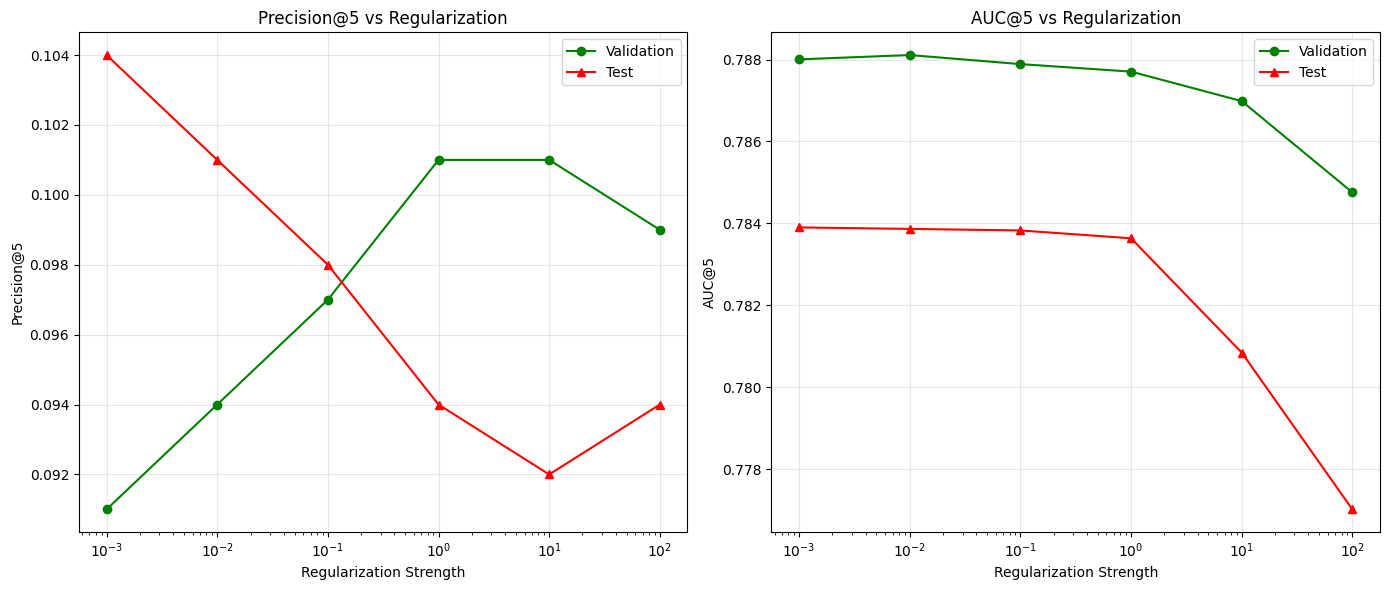

Best model based on test precision:
  Regularization: 0.001
  Test Precision@5: 0.1040
  Test AUC@5: 0.7839


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(
    results_df["regularization"],
    results_df["val_precision"],
    "o-",
    label="Validation",
    color="green",
)
axes[0].plot(
    results_df["regularization"],
    results_df["test_precision"],
    "^-",
    label="Test",
    color="red",
)
axes[0].set_xlabel("Regularization Strength")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Precision@5 vs Regularization")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale("log")

axes[1].plot(
    results_df["regularization"],
    results_df["val_auc"],
    "o-",
    label="Validation",
    color="green",
)
axes[1].plot(
    results_df["regularization"],
    results_df["test_auc"],
    "^-",
    label="Test",
    color="red",
)
axes[1].set_xlabel("Regularization Strength")
axes[1].set_ylabel("AUC@5")
axes[1].set_title("AUC@5 vs Regularization")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

best_idx = results_df["test_precision"].idxmax()
best_reg = results_df.loc[best_idx, "regularization"]
best_test_prec = results_df.loc[best_idx, "test_precision"]
best_test_auc = results_df.loc[best_idx, "test_auc"]

print(f"Best model based on test precision:")
print(f"  Regularization: {best_reg}")
print(f"  Test Precision@5: {best_test_prec:.4f}")
print(f"  Test AUC@5: {best_test_auc:.4f}")

## Hyperparameter Tuning: Number of Factors

In [17]:
factors_to_test = [5, 10, 20, 30, 50]
results = []

print("Testing different numbers of factors...")
for n_factors in factors_to_test:
    print(f"\nTraining with {n_factors} factors...")

    test_model = implicit.als.AlternatingLeastSquares(
        factors=n_factors,
        regularization=0.01,
        iterations=20,
        calculate_training_loss=True,
        random_state=42,
    )

    test_model.fit(final_train_matrix)

    val_prec = precision_at_k_custom(test_model, val_matrix, final_train_matrix, K=5)
    val_auc = calculate_auc(test_model, val_matrix, final_train_matrix, K=100)

    test_prec = precision_at_k_custom(test_model, test_matrix, final_train_matrix, K=5)
    test_auc = calculate_auc(test_model, test_matrix, final_train_matrix, K=100)

    results.append(
        {
            "n_factors": n_factors,
            "val_precision": val_prec,
            "val_auc": val_auc,
            "test_precision": test_prec,
            "test_auc": test_auc,
        }
    )

    print(f"  Val Precision@5: {val_prec:.4f}, AUC: {val_auc:.4f}")
    print(f"  Test Precision@5: {test_prec:.4f}, AUC: {test_auc:.4f}")

results_df = pd.DataFrame(results)

Testing different numbers of factors...

Training with 5 factors...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.0940, AUC: 0.7881
  Test Precision@5: 0.1010, AUC: 0.7839

Training with 10 factors...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.0820, AUC: 0.7888
  Test Precision@5: 0.1130, AUC: 0.7857

Training with 20 factors...


...

  Val Precision@5: 0.0950, AUC: 0.7945
  Test Precision@5: 0.1010, AUC: 0.7899

Training with 30 factors...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.0930, AUC: 0.8017
  Test Precision@5: 0.1030, AUC: 0.7980

Training with 50 factors...


  0%|          | 0/20 [00:00<?, ?it/s]

  Val Precision@5: 0.0900, AUC: 0.8276
  Test Precision@5: 0.1040, AUC: 0.8245


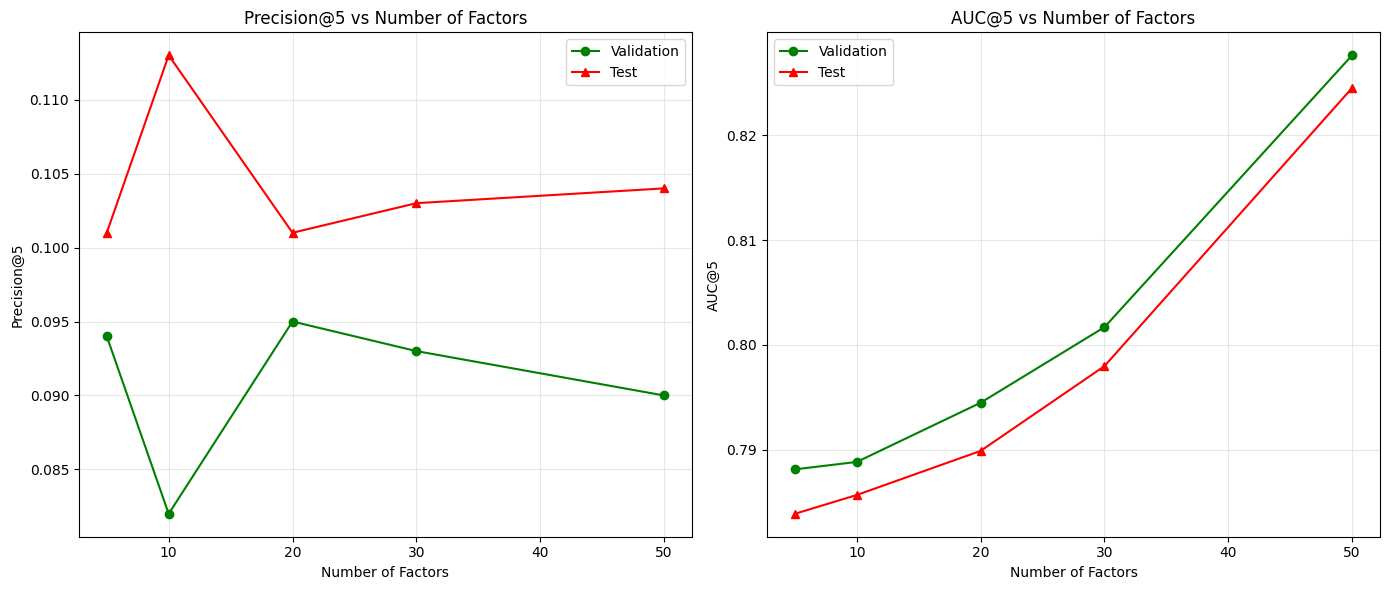

Best model based on test precision:
  Number of factors: 10
  Test Precision@5: 0.1130
  Test AUC@5: 0.7857


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(
    results_df["n_factors"],
    results_df["val_precision"],
    "o-",
    label="Validation",
    color="green",
)
axes[0].plot(
    results_df["n_factors"],
    results_df["test_precision"],
    "^-",
    label="Test",
    color="red",
)
axes[0].set_xlabel("Number of Factors")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Precision@5 vs Number of Factors")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    results_df["n_factors"],
    results_df["val_auc"],
    "o-",
    label="Validation",
    color="green",
)
axes[1].plot(
    results_df["n_factors"],
    results_df["test_auc"],
    "^-",
    label="Test",
    color="red",
)
axes[1].set_xlabel("Number of Factors")
axes[1].set_ylabel("AUC@5")
axes[1].set_title("AUC@5 vs Number of Factors")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = results_df["test_precision"].idxmax()
best_n_factors = results_df.loc[best_idx, "n_factors"]
best_test_prec = results_df.loc[best_idx, "test_precision"]
best_test_auc = results_df.loc[best_idx, "test_auc"]

print(f"Best model based on test precision:")
print(f"  Number of factors: {best_n_factors}")
print(f"  Test Precision@5: {best_test_prec:.4f}")
print(f"  Test AUC@5: {best_test_auc:.4f}")

## Save Model for Future Use

In [19]:
model_with_metadata = {
    "model": model,
    "user_ids": user_ids,
    "item_ids": project_titles,
    "user_ratings": user_ratings,
    "model_params": {
        "factors": model.factors,
        "regularization": model.regularization,
        "iterations": model.iterations,
        "random_state": 42,
    },
    "performance": {
        "val_precision": val_precision,
        "val_auc": val_auc,
        "test_precision": test_precision,
        "test_auc": test_auc,
    },
}

with open("als_model_implicit.pkl", "wb") as f:
    pickle.dump(model_with_metadata, f)

print("Implicit ALS model with metadata saved to als_model_implicit.pkl")
print(f"Model contains: {len(user_ids)} users, {len(project_titles)} items")
print(f"Stored actual ratings for {len(user_ratings)} users")

Implicit ALS model with metadata saved to als_model_implicit.pkl
Model contains: 200 users, 1187 items
Stored actual ratings for 200 users


In [20]:
user_ids

['international_relations_geopolitics_expert',
 'international_relations_regional_studies_enthusiast',
 'international_relations_law_and_security_analyst',
 'international_relations_student_and_ambassador',
 'sociology_culture_and_identity_expert',
 'intercultural_communication_and_global_studies',
 'social_and_political_theory_researcher',
 'social_and_youth_issues_specialist',
 'macroeconomic_and_geopolitical_analyst',
 'russian_economic_policy_expert',
 'international_business_and_trade_specialist',
 'applied_economics_and_fintech_practitioner',
 'linguistics_translator_and_corpus_builder',
 'cross_cultural_communicator_specialist',
 'language_curriculum_developer',
 'computational_linguistics_and_NLP_enthusiast',
 'education_tech_developer',
 'full_stack_mobile_developer',
 'data_and_system_architect',
 'media_and_community_builder',
 'digital_marketing_strategist',
 'brand_management_and_rebranding_expert',
 'media_and_PR_specialist',
 'market_research_and_consumer_insights',
 'cu